# <center>**P12**</center>

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Étape 1 : Analyse descriptive et préparation des données</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Importation des librairies</h3>
</div>

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "5"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.decomposition import PCA

# Évaluation des modèles
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,   # métriques de performance
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,    # courbe ROC et matrice de confusion
    classification_report                                       # rapport de classification complet
)

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Fonction</h3>
</div>

In [2]:
# --- FONCTION POUR EXPLORATION DES DONNÉES ---

def inspector(df):
    # Debut de l'inspection
    print("#####     DEBUT DE L'INSPECTION     ############################################")
    
    # Structure du DataFrame avec df.shape
    print("\n----------------------")
    print("Structure du DataFrame:")
    print(f'Nb de lignes: {df.shape[0]} ; Nb de colonnes: {df.shape[1]}')
    
    # Types de données avec df.dtypes
    print("\n----------------------")
    print("Types de données:")
    print(df.dtypes)

    # Présence de doublons # ajout
    print("\n----------------------")
    print(f"Nombre de doublons: {df.duplicated().sum()}")
    
    # Présence d'une potentielle clé unique (identifiant) avec df.nunique()
    print("\n----------------------")
    print("Nombre de valeurs uniques (pour identifiant PK / FK):")
    print(df.nunique())
    
    # Présence de valeurs manquantes avec df.isnull().sum()
    print("\n----------------------")
    print("Valeurs manquantes:")
    print(df.isnull().sum())    
    
    # Fin de l'inspection
    print("\n#####     FIN DE L'INSPECTION     ############################################")

    
    # Affichage du tableau
    print("\n#####      APERÇU DU TABLEAU      ############################################")    
    display(df)
    print("\n##############################################################################")

In [3]:
# --- FONCTION POUR AFFICHER LA MATRICE DE CONFUSION ---

def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Faux", "Vrai"],
        yticklabels=["Faux", "Vrai"],
    )
    plt.title(f"Matrice de Confusion - {model_name}")
    plt.ylabel("Réalité")
    plt.xlabel("Prédiction")
    plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Chargement du fichier</h3>
</div>

In [4]:
df_billets = pd.read_csv('données/billets.csv', sep=';')

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Préparation des données</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Inspection des données</h3>
</div>

In [5]:
# --- Nettoyage ---
df = df_billets.copy()
print("📊 --- INSPECTION DES DONNÉES ---")
print("")

inspector(df)

📊 --- INSPECTION DES DONNÉES ---

#####     DEBUT DE L'INSPECTION     ############################################

----------------------
Structure du DataFrame:
Nb de lignes: 1500 ; Nb de colonnes: 7

----------------------
Types de données:
is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

----------------------
Nombre de doublons: 0

----------------------
Nombre de valeurs uniques (pour identifiant PK / FK):
is_genuine        2
diagonal        159
height_left     155
height_right    170
margin_low      285
margin_up       123
length          336
dtype: int64

----------------------
Valeurs manquantes:
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

#####     FIN DE L'INSPECTION     ############################################

#####      APERÇU DU TABLE

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25



##############################################################################


In [6]:
# Affiche le nombre de billets vrais et faux parmi les valeurs manquantes
print(df[df['margin_low'].isna()]['is_genuine'].value_counts())
display(df[df['margin_low'].isna()])

is_genuine
True     29
False     8
Name: count, dtype: int64


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
72,True,171.94,103.89,103.45,NaN,3.25,112.79
99,True,171.93,104.07,104.18,NaN,3.14,113.08
151,True,172.07,103.80,104.38,NaN,3.02,112.93
197,True,171.45,103.66,103.80,NaN,3.62,113.27
241,True,171.83,104.14,104.06,NaN,3.02,112.36
251,True,171.80,103.26,102.82,NaN,2.95,113.22
284,True,171.92,103.83,103.76,NaN,3.23,113.29
334,True,171.85,103.70,103.96,NaN,3.00,113.36
410,True,172.56,103.72,103.51,NaN,3.12,112.95
413,True,172.30,103.66,103.50,NaN,3.16,112.95


Dans notre data set, parmi **les billets n'ayant pas la variable `margin_low` renseignée**, on retrouve :
<br>- **29 vrais billets**
<br>- **8 faux billets**

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Analyse descriptive (Répartition et Dimensions)</h3>
</div>

In [7]:
# Vérification de la répartition des classes (Vrai/Faux)
print("\n--- Répartition des types de billets ---")
print("")
print(df["is_genuine"].value_counts())
print("")

# Statistiques descriptives globales et par catégorie (Vrai/Faux)
print("\n--- Statistiques descriptives globales ---")
print("")
display(df.describe())
print("")

print("\n--- Statistiques descriptives par groupe (Vrai/Faux) ---")
print("")
# On groupe par la colonne de nature du billet
display(df.groupby("is_genuine").mean())
print("")


--- Répartition des types de billets ---

is_genuine
True     1000
False     500
Name: count, dtype: int64


--- Statistiques descriptives globales ---



,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000




--- Statistiques descriptives par groupe (Vrai/Faux) ---



,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,,,,,,
False,171.90116,104.19034,104.14362,5.215935,3.35016,111.63064
True,171.98708,103.94913,103.80865,4.116097,3.05213,113.20243


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Visualisations graphiques</h3>
</div>

In [8]:
# Configuration du style des graphiques
sns.set_theme(style="whitegrid")

features_geom = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

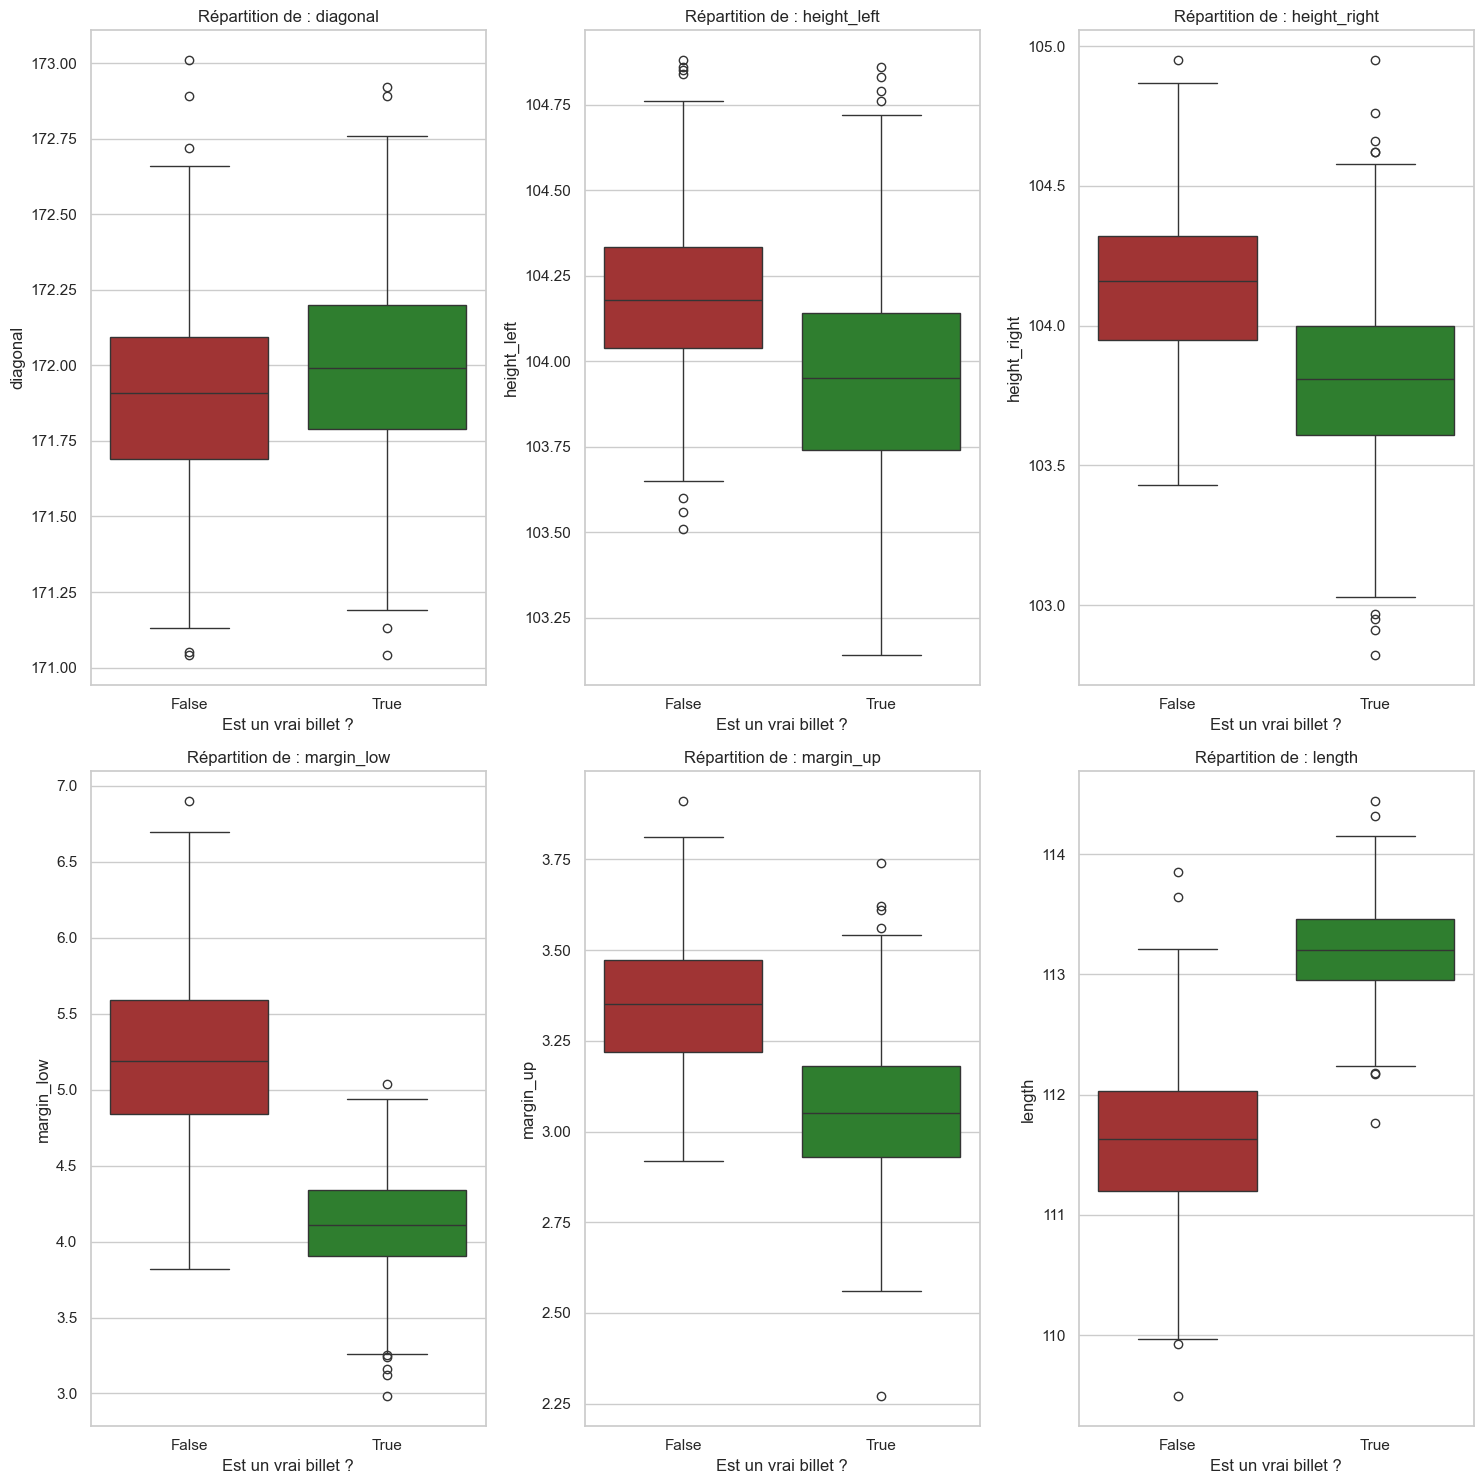

In [9]:
# Boxplots pour observer la séparation des dimensions
plt.figure(figsize=(15, 15))
couleurs_custom = {True: "forestgreen", False: "firebrick"}
for i, col in enumerate(features_geom, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x="is_genuine", y=col, hue="is_genuine", palette=couleurs_custom, legend=False)
    plt.title(f"Répartition de : {col}")
    plt.xlabel("Est un vrai billet ?")
plt.tight_layout()
plt.show()

Les boxplot nous permettent d'identifier visuellement quelles caractéristiques physiques permettent de distinguer un vrai billet d'un faux.

**Si les deux boxplots (Vrai/Faux) ne sont pas symétrique verticalement, cela signifie que cette caractéristique est un excellent indicateur pour notre modèle de Machine Learning**.

On observe que 'lenght', 'margin_low' et 'margin_up' semblent être de bons indicateurs pour discerner un vrai billet d'un faux.

Si les deux boxplots sont symétrique (ou presque), cela indique que cette caractéristique est similaire chez les vrais et les faux billets. Elle sera donc beaucoup moins utile pour faire la distinction. On observe cette quasi-symétrie pour la caractéristique 'diagonale'.

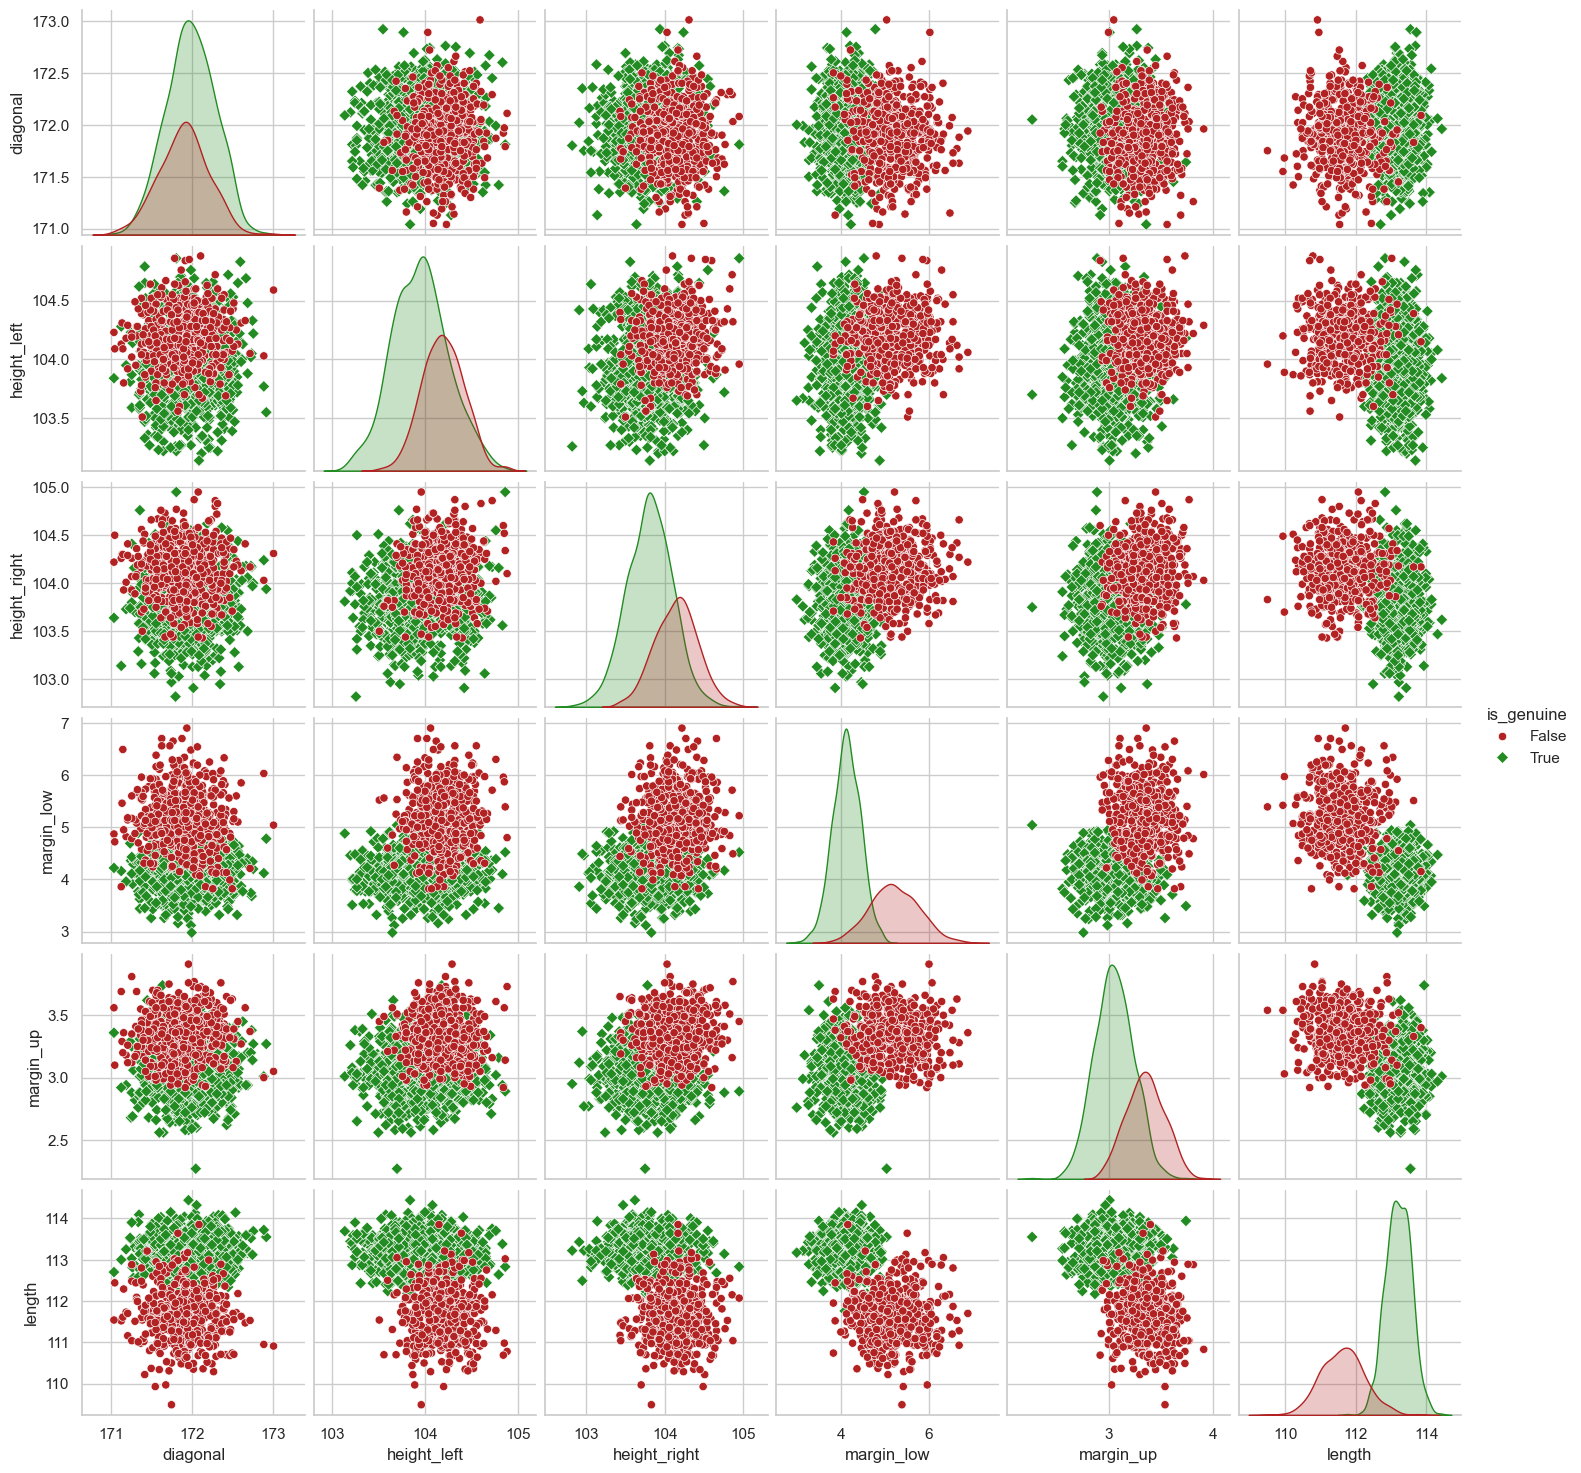

In [10]:
sns.pairplot(data=df, hue='is_genuine', markers=["o", "D"], palette=couleurs_custom)
plt.show()

L'observation globale des graphiques montre que **les vrais (en vert) et les faux (en rouge) billets forment des clusters relativement distincts.** Cela indique que les dimensions géométriques des billets contiennent un signal fort, ce qui permettra à un modèle de classification d'obtenir d'excellentes performances pour détecter les faux billets.

D'après les courbes de distribution et les croisements, certaines variables se détachent nettement car leurs courbes ne se chevauchent presque pas :
- **length (Longueur)** semble être la variable la plus puissante. La distribution montre que les vrais billets (verts) sont globalement plus longs (concentrés autour de 113.5 mm) que les faux billets (rouges, concentrés autour de 111.5 mm). Le croisement de length avec n'importe quelle autre variable montre deux blocs bien séparés.
- **margin_low** (marges inférieure) et **margin_up** (marges supérieure) nous montre que les faux bilets ont tendance à avoir des marges plus grandes (plus hautes) que les vrais billets : on observe sur les graphiques de distribution que les pics verts et rouges sont bien décalés.

D'autres caractéristiques physiques présentent un fort chevauchement :

- les courbes de distribution des vrais et faux billets de la variable **diagonal** sont presque confondues au même endroit. **La diagonale seule ne permet absolument pas de distinguer un vrai billet d'un faux.**
- pour les variables **height_left** (hauteurs gauche) et **height_right** (hauteurs droite), la **zone de recouvrement des points reste très dense** même si l'on observe un léger décalage (les faux billets ont tendance à être légèrement plus hauts).

Nous avons donc un **absence de linéarité parfaite mais des clusters clairs**. Il n'y a **pas de corrélation linéaire flagrante** entre les variables explicatives elles-mêmes (les nuages de points ressemblent plutôt à des cercles ou des blocs, pas à des lignes droites), **mais la séparation par couleur est nette**.

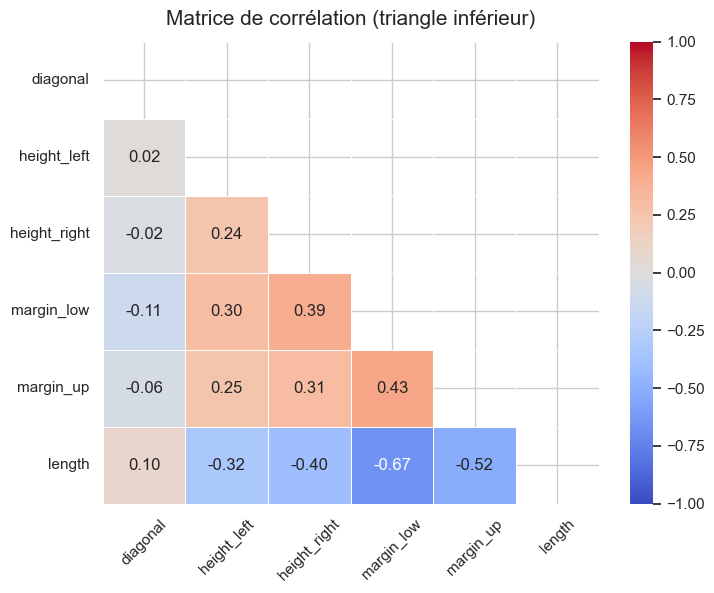

In [11]:
plt.figure(figsize=(8, 6))

# 1. Calcul de la matrice de corrélation
corr = df[features_geom].corr()

# 2. Création du masque pour la moitié supérieure
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Affichage de la heatmap avec les limites d'échelle vmin et vmax
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1,  # Valeur minimale de l'échelle
    vmax=1   # Valeur maximale de l'échelle
)

plt.xticks(rotation=45) 
plt.yticks(rotation=0)
plt.title("Matrice de corrélation (triangle inférieur)", fontsize=15, pad=12)
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Corrélation de chaque caractéristique avec la cible</h3>
</div>

In [12]:
print(df[features_geom].corrwith(df['is_genuine'].astype(int)).sort_values(ascending=False))

length          0.849285
diagonal        0.132756
height_left    -0.379833
height_right   -0.485092
margin_up      -0.606262
margin_low     -0.783032
dtype: float64


***Comprendre les résultats :***

<br>**Proche de 1** : Forte corrélation positive (si la variable augmente, la probabilité du billet d'être authentique augmente).
<br>**Proche de 0** : Aucune relation linéaire.
<br>**Proche de -1** : Forte corrélation négative (si la variable augmente, la probabilité du billet d'être authentique baisse).
<br>
<br>
<br>
***Ainsi, on observe :***
<br>
<br>- **length (0.85)** : Très forte corrélation positive. **Plus le billet est long, plus il a de chances d'être authentique.**
<br>
<br>- **diagonal (0.13)** : Corrélation positive très faible. **La diagonale seule ne permet pas de différencier efficacement un vrai billet d'un faux.**
<br>
<br>- **height_left (-0.38)** et **height_right (-0.49)** : Corrélation négative modérée. **Les faux billets ont tendance à être légèrement plus hauts (à gauche comme à droite) que les vrais.**
<br>
<br>- **margin_up (-0.61)** et **margin_low (-0.78)** : Forte corrélation négative. **Plus la marge supérieure ou inférieure est grande, plus le billet a de chances d'être une contrefaçon.**
<br>
<br>
<br>***Cela confirme ce qui a été déduit avec les boxplots juste avant.***

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Prétraitement</h2>
</div>

Le but est de transformer les données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.

<br>D'abord, il faut séparer les variables explicatives et la cible :
<br>=> X = les mesures du billet (longueur, hauteur, diagonales…)
<br>=> y = l’étiquette (vrai ou faux)

**Pourquoi ?** Parce que le modèle doit apprendre à prédire y en fonction de X.

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Séparation du dataset (train/test)</h3>
</div>

In [13]:
# Préparation des variables

X = df[features_geom] # Toutes les colonnes sauf la cible (colonnes contenant les mesures géométriques des billets)
y = df['is_genuine'] # La colonne cible

# Vérification des dimensions
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (1500, 6)
Dimensions de y : (1500,)


De plus, on entraîne **toujours** le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ **Pourquoi ?** Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

Nous séparons les données en deux parties :

- un jeu d'entraînement pour apprendre le modèle ;
- un jeu de test pour évaluer sa capacité à généraliser sur des billets jamais vus.

Le paramètre `stratify=y` permet de conserver la même proportion de vrais et faux billets dans les deux jeux.

In [14]:
# Séparation du dataset pour l'entraînement (Train = 80%) et pour le test (Test = 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print()
print(f"Taille du jeu d'entraînement: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Taille du jeu de test : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("-"*50)
print("\nRépartition des classes dans le jeu d'entraînement :")
for classe, count in y_train.value_counts().items():
    pct = count / len(y_train) * 100
    print(f"{classe}: {count} ({pct:.2f}%)")
print()
print("-"*50)
print("\nRépartition des classes dans le jeu de test :")
for classe, count in y_test.value_counts().items():
    pct = count / len(y_test) * 100
    print(f"{classe}: {count} ({pct:.2f}%)")
print()


Taille du jeu d'entraînement: 1200 (80%)
Taille du jeu de test : 300 (20%)

--------------------------------------------------

Répartition des classes dans le jeu d'entraînement :
True: 800 (66.67%)
False: 400 (33.33%)

--------------------------------------------------

Répartition des classes dans le jeu de test :
True: 200 (66.67%)
False: 100 (33.33%)



**Vérification de la stratification**

La répartition des classes est conservée dans les deux jeux (entraînement et test) :

- jeu d'entraînement : environ 66,7 % de vrais billets et 33,3 % de faux billets ;
- jeu de test : environ 66,7 % de vrais billets et 33,3 % de faux billets.

Cette stratification permet d'évaluer les modèles sur un jeu de test représentatif du jeu de données initial.

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Traitement des valeurs manquantes - Imputation par la médiane</h3>
</div>

In [16]:
# Imputation par la médiane
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features_geom,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features_geom,
    index=X_test.index
)

In [17]:
# Vérification
print(X_train.isna().sum())
print()
X_train.info()

diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 122 to 542
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      1200 non-null   float64
 1   height_left   1200 non-null   float64
 2   height_right  1200 non-null   float64
 3   margin_low    1200 non-null   float64
 4   margin_up     1200 non-null   float64
 5   length        1200 non-null   float64
dtypes: float64(6)
memory usage: 65.6 KB


In [18]:
# Vérification
print(X_test.isna().sum())
print()
X_test.info()

diagonal        0
height_left     0
height_right    0
margin_low      0
margin_up       0
length          0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 803 to 879
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      300 non-null    float64
 1   height_left   300 non-null    float64
 2   height_right  300 non-null    float64
 3   margin_low    300 non-null    float64
 4   margin_up     300 non-null    float64
 5   length        300 non-null    float64
dtypes: float64(6)
memory usage: 16.4 KB


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Standardisation des données</h3>
</div>

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [19]:
# Dans la base de donnée d'entraînement
# Normalisation du jeu d'entraînement (indispensable pour Régression Logistique, KNN et K-means)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_geom, index=X_train.index)
X_train_scaled.describe().round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.07,-2.97,-3.13,-2.11,-3.82,-3.65
25%,-0.67,-0.71,-0.66,-0.69,-0.70,-0.74
50%,0.00,0.03,0.00,-0.26,-0.05,0.33
75%,0.67,0.66,0.72,0.59,0.68,0.75
max,3.50,2.83,3.20,3.71,3.28,2.03


In [20]:
# Dans la base de donnée de test
# Normalisation du jeu de test (indispensable pour Régression Logistique, KNN et K-means)
#X_test_scaled = scaler.transform(X_test)
#X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_geom)


X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_geom, index=X_test.index)
X_test_scaled.describe().round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,-0.02,-0.03,0.02,-0.05,-0.01,0.06
std,1.08,0.99,1.05,1.05,1.02,1.01
min,-2.73,-2.61,-3.41,-2.32,-2.56,-2.81
25%,-0.74,-0.74,-0.63,-0.77,-0.76,-0.70
50%,-0.05,0.04,0.00,-0.26,-0.01,0.39
75%,0.81,0.64,0.75,0.50,0.73,0.83
max,3.10,2.66,2.61,3.19,2.85,1.68


La moyenne (mean) n'est pas exactement à 0.

L'écart-type (std) n'est pas exactement à 1.

C'est normal, le jeu de test est légèrement différent du jeu d'entraînement, appliquer la moyenne et l'écart-type du Train sur le Test donne des résultats proches de 0 et 1, mais pas parfaits. Si on obtenait exactement 0 et 1, cela signifierait que l'on a fait une erreur en ré-appliquant un fit sur le test.

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Conclusion de l'analyse exploratoire</h3>
</div>

L’analyse exploratoire a permis de mieux comprendre la structure du dataset ainsi que les principales différences entre les vrais billets et les faux billets.

Les visualisations (boxplots et matrice de corrélation) montrent que certaines variables géométriques sont particulièrement discriminantes :

### Variables les plus discriminantes
- `length`
- `margin_low`
- `margin_up`

Ces variables présentent les écarts les plus marqués entre vrais et faux billets et semblent jouer un rôle majeur dans l’identification des contrefaçons.

### Variables modérément discriminantes
- `height_right`
- `height_left`

Ces variables apportent également de l’information, mais leur pouvoir de séparation des vrais et faux billets reste plus limité.

### Variable faiblement discriminante
- `diagonal`

La variable `diagonal` présente une capacité de séparation nettement plus faible.

L’analyse a également mis en évidence la présence de **37 valeurs manquantes** dans la variable `margin_low`, soit environ **2,47 %** du dataset.

Ces valeurs manquantes ont été traitées lors de la phase de prétraitement afin de conserver l’ensemble des observations.

Le jeu de données est maintenant prêt pour la phase de préparation et de modélisation.

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">ACP</h2>
</div>

In [21]:
# Application de l'ACP sur les données standardisées
pca = PCA(n_components=X_train_scaled.shape[1])
X_projected = pca.fit_transform(X_train_scaled)

# Calcul des pourcentages de variance
variance_individuelle = pca.explained_variance_ratio_ * 100
variance_cumulee = variance_individuelle.cumsum()

# Résultats dans un tableau
pd.DataFrame({
    'Valeur propre': pca.explained_variance_.round(2),
    'Variance (en %)': variance_individuelle.round(2),
    'Variance cumulée (en %)': variance_cumulee.round(2)
}, index=[f'F{i+1}' for i in range(len(variance_individuelle))])

,Valeur propre,Variance (en %),Variance cumulée (en %)
F1,2.59,43.13,43.13
F2,1.02,17.06,60.19
F3,0.77,12.91,73.10
F4,0.72,11.96,85.06
F5,0.58,9.60,94.65
F6,0.32,5.35,100.00


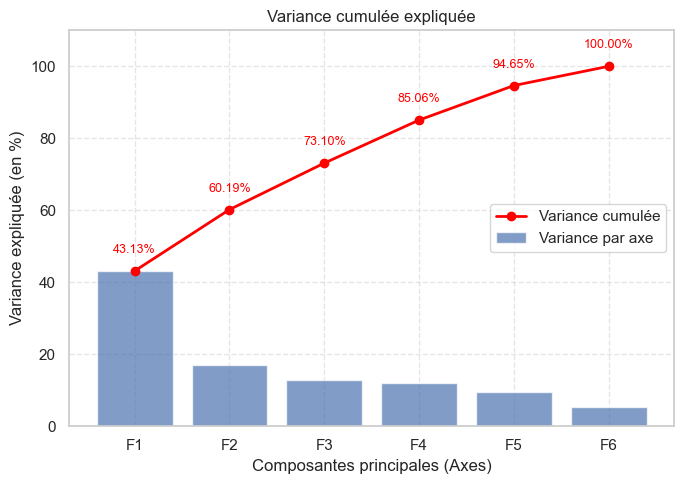

In [22]:
# Graphique des pourcentages de variance
# Définition unique des positions et des labels pour éviter les répétitions
num_axes = len(features_geom)
positions = range(1, num_axes + 1)
labels_axes = [f"F{i}" for i in positions]

# Eboulis des valeurs propres
plt.figure(figsize=(7, 5))

# Barres pour l'apport de chaque axe
plt.bar(
    positions,
    variance_individuelle,
    alpha=0.7,
    label="Variance par axe",
)


# Ligne rouge pour le cumul de l'information
plt.plot(
    positions,
    variance_cumulee,
    color="red",
    marker="o",
    linewidth=2,
    label="Variance cumulée",
)


for i, val in enumerate(variance_cumulee):
    plt.text(i + 1, val + 5, f"{val:.2f}%", ha="center", fontsize=9, color="red")

plt.xlabel("Composantes principales (Axes)")
plt.ylabel("Variance expliquée (en %)")
plt.title("Variance cumulée expliquée")
plt.ylim(0, 110)
plt.legend(loc="center right")
plt.grid(True, linestyle="--", alpha=0.5)


plt.xticks(positions, labels_axes)
plt.tight_layout()  # Aligne automatiquement les marges
plt.show()

On observe que le **premier axe principal (F1) capte à lui seul 43,13 % de la variance totale**. C'est une part très importante qui montre qu'il existe une direction de variabilité majeure et structurante dans les données.

Les **deux premiers axes cumulent, à eux seuls, 60,19% de l'information totale.**

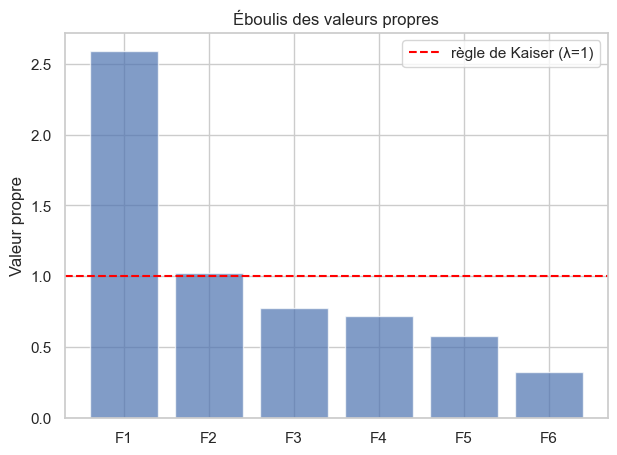

In [23]:
# Graphique de l'éboulis des valeurs propres (un seul graphique)
fig, ax = plt.subplots(figsize=(7, 5))
axes = [f'F{i+1}' for i in range(len(variance_individuelle))]

# Utilisation de 'ax' au lieu de 'ax1'
ax.bar(axes, pca.explained_variance_, alpha=0.7)

ax.axhline(y=1, color='red', linestyle='--', label='règle de Kaiser (λ=1)')
# trace une ligne horizontale rouge en pointillés à y=1 -> le seuil de Kaiser

ax.set_title('Éboulis des valeurs propres')
ax.set_ylabel('Valeur propre')
ax.legend()

plt.show()

Selon la règle de Kaiser, on ne garde que les axes dont la **valeur propre est supérieure à 1 pour les valeurs propres brutes : on garde donc 2 axes.**

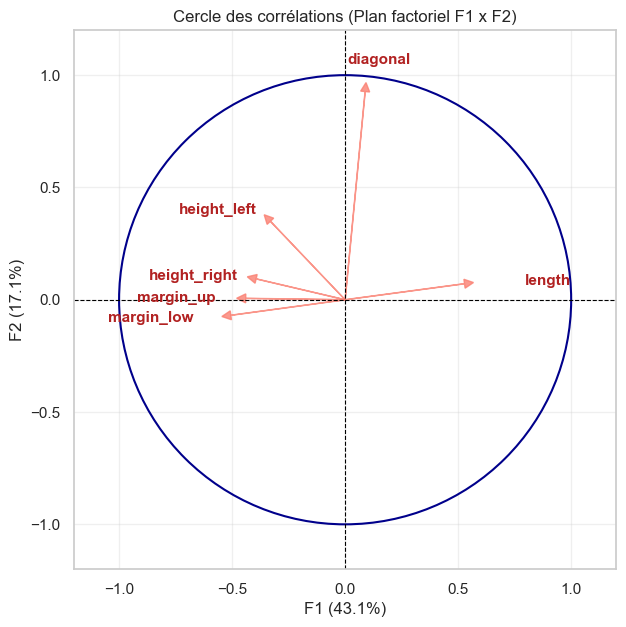

In [24]:
# CERCLE DES CORRÉLATIONS (F1, F2)

pcs = pca.components_

plt.figure(figsize=(7, 7))

# Dessin du cercle unité (rayon = 1)
circle = plt.Circle((0, 0), 1, facecolor="none", edgecolor="darkblue", linestyle="-", linewidth=1.5)
plt.gca().add_artist(circle)

# Tracé des flèches pour chaque variable géométrique
for i, var in enumerate(features_geom):
    x_arrow = pcs[0, i]
    y_arrow = pcs[1, i]

    # Dessin de la flèche
    plt.arrow(
        0,
        0,
        x_arrow,
        y_arrow,
        head_width=0.04,
        head_length=0.04,
        color="salmon",
        alpha=0.8,
    )

    # Positionnement du texte de la variable légèrement décalé de la flèche
    plt.text(
        x_arrow * 1.7,
        y_arrow * 1.15,
        var,
        color="firebrick",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
    )

# Configuration des axes géométriques du cercle
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)

plt.xlabel(f"F1 ({variance_individuelle[0]:.1f}%)")
plt.ylabel(f"F2 ({variance_individuelle[1]:.1f}%)")
plt.title("Cercle des corrélations (Plan factoriel F1 x F2)")
plt.grid(True, alpha=0.3)
plt.show()

La variable `diagonal` touche presque le bord du cercle : elle est extrêmement bien représentée sur ce plan, spécifiquement par l'axe F2. Les variables `margin_up`, `margin_low`, `height_right` et `height_left` tirent fortement vers la gauche (corrélées négativement à F1). La variable `length` va vers la droite (corrélée positivement à F1).

L'axe F1 (avec 43.1% d'information) oppose la longueur (`length`, à droite) aux dimensions/marges du billet (`margin_up`, `margin_low`, `height_left`, `height_right`, à gauche).

L'axe F2 (avec 17.1% d'information) est quant à lui presque uniquement défini par la diagonale (`diagonal`, tout en haut).

Les variables liées aux hauteurs et aux marges (`margin_up`, `margin_low`, `height_left`, `height_right`) forment un faisceau de flèches pointant dans la même direction (angle aigu) : elles sont fortement corrélées positivement entre elles. En revanche, elles sont corrélées négativement à `length` (angle proche de $180^\circ$).

En résumé, **le premier axe synthétise la forme globale et les proportions des contours** (opposition longueur vs hauteurs/marges), tandis que **le second axe capte spécifiquement l'information liée à la diagonale.**

In [25]:
# Coefficients bruts de chaque variable sur F1 et F2
contributions = pd.DataFrame({
    "F1": pca.components_[0],
    "F2": pca.components_[1],
}, index=features_geom)

# On trie selon la valeur absolue de F1
display(contributions.sort_values(by="F1", ascending=False, key=lambda x: x.abs()))

,F1,F2
length,0.528132,0.071299
margin_low,-0.505584,-0.069204
margin_up,-0.439744,0.006090
height_right,-0.393689,0.092964
height_left,-0.330528,0.349396
diagonal,0.088583,0.927022


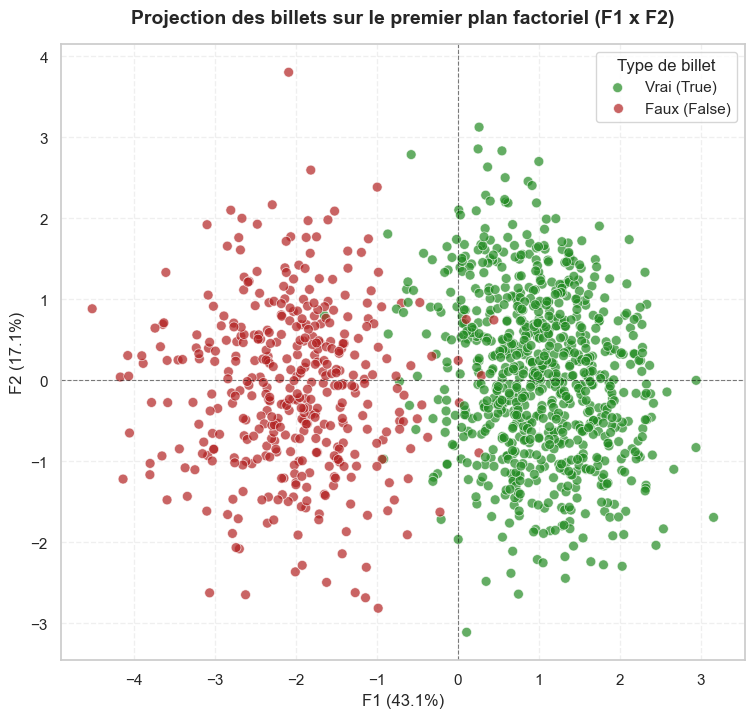

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Création d'un DataFrame temporaire pour faciliter le tracé avec Seaborn
# On utilise les coordonnées des deux premières composantes (colonnes 0 et 1)
df_projection = pd.DataFrame(
    {
        "F1": X_projected[:, 0],
        "F2": X_projected[:, 1],
        "Statut": y_train,  # On utilise le y de l'entraînement qui fait aussi 1200 lignes
    }
)

# Création du graphique
plt.figure(figsize=(10, 8))

# Tracé des points
# On colore par 'Statut' avec une palette de couleurs contrastées. On utilise le même code couleur que définit plus haut avec 'couleurs_custom'
sns.scatterplot(
    data=df_projection,
    x="F1",
    y="F2",
    hue="Statut",
    palette=couleurs_custom,
    alpha=0.7,
    s=50,  # Taille des points
)

# Traçage des axes x=0 et y=0
plt.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

# Labels et titre
plt.xlabel(f"F1 ({variance_individuelle[0]:.1f}%)")
plt.ylabel(f"F2 ({variance_individuelle[1]:.1f}%)")
plt.title(
    "Projection des billets sur le premier plan factoriel (F1 x F2)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

# Esthétique du graphique pour une meilleure lisibilité
plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(title="Type de billet", labels=["Vrai (True)", "Faux (False)"])
plt.show()

**La projection des individus sur le premier plan factoriel (F1) révèle une séparation nette et remarquable entre les vrais et les faux billets.**

Cette séparation s'opère quasi exclusivement le long de l'axe F1 (43,1 % de variance). Le nuage des vrais billets (représenté en vert) se concentre de manière homogène dans la partie positive de l'axe F1. À la lumière de l'analyse des variables, cela démontre que les vrais billets se caractérisent par une longueur (length) supérieure et des dimensions de contours (marges et hauteurs) plus restreintes.

À l'inverse, le nuage des faux billets (en rouge) se situe dans la partie négative de l'axe F1, traduisant des billets globalement plus courts, mais dotés de marges (margin_up / margin_low) et de hauteurs anormalement grandes. L'axe F2, quant à lui, montre une dispersion similaire pour les deux classes et ne participe pas directement à leur discrimination.

**L'ACP confirme ainsi que les contours géométriques extérieurs constituent des indicateurs discriminants majeurs pour détecter les faux billets.** 

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">COMPARAISON DE 4 MODÈLES</h2>
</div>

# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">MODÈLE : Régression Logistique Classique</h3>
</div>

La **régression logistique** est un **modèle supervisé** utilisé pour les problèmes de **classification binaire**.

Dans notre cas, elle doit prédire deux classes :

- vrai billet ;
- faux billet.

In [27]:
# 1) Initialisez une régression logistic.
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2) Entrainez le modèle avec vos données X_train et y_train
log_reg.fit(X_train_scaled, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probabilités d'être un vrai billet

print("✅ Régression logistique entraînée avec succès.")

✅ Régression logistique entraînée avec succès.


**Évaluation de la régression logistique**

Une fois le modèle entraîné, nous évaluons ses performances sur le jeu de test.

Le rapport de classification fournit :

- la précision (precision) ;
- le rappel (recall) ;
- le F1-score ;
- le support (nombre d'observations par classe).

Ces indicateurs permettent d'évaluer la capacité du modèle à distinguer les vrais billets des faux billets.

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



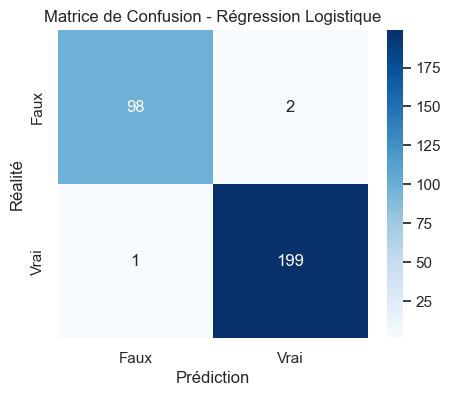

In [28]:
# Régression linéaire
print(classification_report(y_test, y_pred_lr))
cm_lr = confusion_matrix(y_test, y_pred_lr)
plot_confusion_matrix(cm_lr, "Régression Logistique")

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">MODÈLE : KNN (K-Nearest Neighbors)</h3>
</div>

Le **KNN** est un **modèle supervisé** basé sur la **distance entre les observations**.

Pour prédire un nouveau billet, le modèle regarde les billets les plus proches dans le jeu d'entraînement.

Ce modèle est sensible à l’échelle des variables, c’est pourquoi la standardisation est indispensable.

In [29]:
# 1) Initialisez KNN
knn = KNeighborsClassifier(
    n_neighbors=5
)

# 2) Entrainez le modèle avec vos données X_train et y_train
knn.fit(X_train_scaled, y_train)

# 3) Utiliser le KNN pour déterminer les vrais / faux billets de X_test.

# Prédiction sur les données de test
y_pred_knn = knn.predict(X_test_scaled)
# Probabilités de prédiction
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
print("✅ KNN entraîné avec succès.")

✅ KNN entraîné avec succès.


              precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



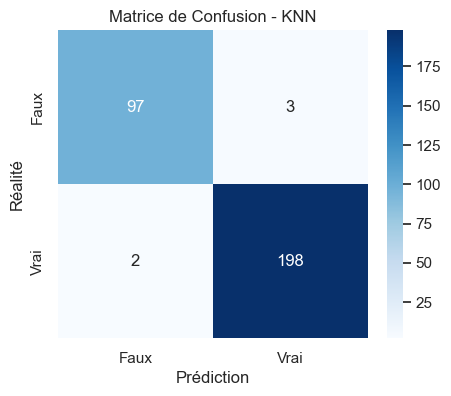

In [30]:
# KNN
print(classification_report(y_test, y_pred_knn))
cm_knn = confusion_matrix(y_test, y_pred_knn)
plot_confusion_matrix(cm_knn, "KNN")

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">MODÈLE : Random Forest</h3>
</div>

Le **Random Forest** est un **modèle supervisé** basé sur un **ensemble d’arbres de décision**.

Chaque arbre apprend une partie du problème, puis le modèle combine les décisions de tous les arbres.

Ce modèle est souvent performant car il capture des relations non linéaires entre les variables.

**Particularité du prétraitement pour le Random Forest**

Contrairement à la régression logistique, au KNN et au K-Means, le Random Forest n'est pas sensible à l'échelle des variables.

Il n'est donc pas nécessaire d'appliquer une standardisation avec `StandardScaler`.

Seule l'imputation des valeurs manquantes est réalisée avant l'entraînement, nous utiliserons donc X_train qui n'a eu que l'imputation à la médiane lors de la phase de prétraitement.

Cette approche permet de conserver les valeurs originales des variables tout en garantissant l'absence de données manquantes.

In [31]:
# 1) Initialisez Random Forest
# Pas strictement dépendant de la normalisation, mais fonctionne parfaitement avec
rf = RandomForestClassifier(random_state=42, n_estimators=100)

# 2) Entrainez le modèle avec vos données X_train et y_train
rf.fit(X_train, y_train)  # On peut utiliser X_train non standardisé pour les arbres

# 3) Utiliser Random Forest pour déterminer les vrais / faux billets de X_test.
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



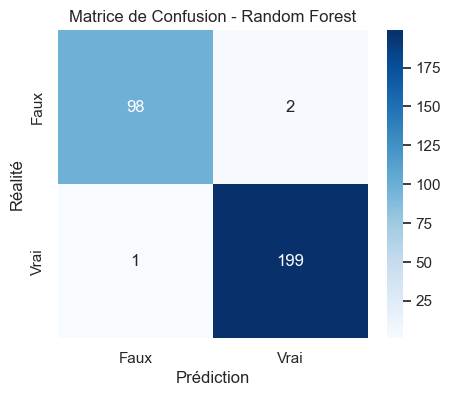

In [32]:
# Random Forest
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrix(cm_rf, "Random Forest")

In [33]:
# Récupération des importances calculées par le Random Forest
importances = rf.feature_importances_

# Création d'un DataFrame pour faciliter la lecture
importance_df = pd.DataFrame({
    "Variable": features_geom,
    "Importance": importances
})

# Tri décroissant
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Affichage du tableau
importance_df

,Variable,Importance
5,length,0.495741
3,margin_low,0.310365
4,margin_up,0.103669
2,height_right,0.046692
1,height_left,0.034306
0,diagonal,0.009227


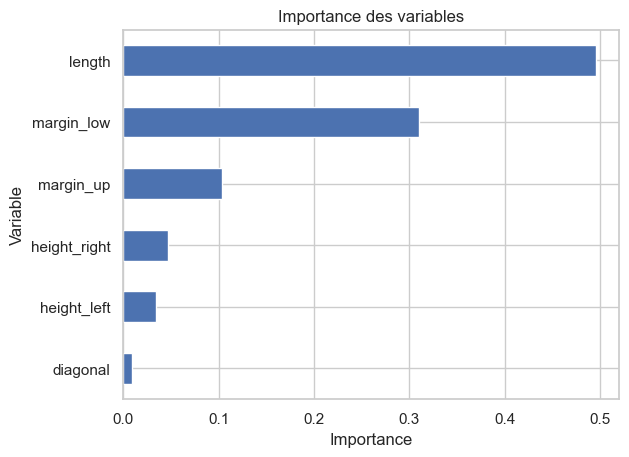

In [34]:
pd.Series(
    rf.feature_importances_, 
    index=features_geom
).sort_values().plot(kind='barh', title='Importance des variables')

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

**Interprétation des importances**

L'analyse des importances calculées par le Random Forest confirme les observations réalisées lors de l'analyse exploratoire.

La variable la plus importante est la longueur du billet (`length`), qui représente à elle seule plus de 50 % du pouvoir prédictif du modèle.

Les variables `margin_low` et `margin_up` occupent respectivement la deuxième et la troisième position.

Ces trois variables représentent ensemble plus de 90 % de l'information utilisée par le modèle pour distinguer les vrais billets des faux billets.

À l'inverse, les variables `height_left`, `height_right` et `diagonal` contribuent beaucoup moins à la décision finale.

Cette analyse confirme que **les dimensions liées aux marges et à la longueur** du billet constituent les **principaux indicateurs de contrefaçon dans ce jeu de données**.

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">MODÈLE : K-Means (Classification par Centroïdes)</h3>
</div>

Le K-means est un algorithme **non supervisé**.

Contrairement aux modèles précédents, il n’utilise pas la variable cible `is_genuine` pendant l’entraînement.

Il cherche simplement à former deux groupes de billets à partir des dimensions géométriques.

Ensuite, nous comparons les groupes créés avec les vraies étiquettes pour voir si les clusters correspondent aux vrais et faux billets.

Le K-means calcule des distances euclidiennes ; il est donc crucial que toutes les variables soient à la même échelle.

C'est le cas avec la normalisation des données effectué précédemment

In [35]:
print("K-MEANS CLASSIFICATION & EVALUATION")

# Initialisation du K-means avec 2 clusters
kmeans_sup = KMeans(n_clusters=2, random_state=42, n_init=10)

# Entraînement et prédiction (On stocke dans un tableau NumPy indépendant pour isoler X_train)
train_clusters = kmeans_sup.fit_predict(X_train_scaled)

# Affichage de la répartition numérique
print("\n--- Répartition des billets par cluster trouvé (Train Set) ---")
print(pd.Series(train_clusters).value_counts())

K-MEANS CLASSIFICATION & EVALUATION

--- Répartition des billets par cluster trouvé (Train Set) ---
1    806
0    394
Name: count, dtype: int64


In [36]:
# Évaluation : Calcul du coefficient de silhouette
sil_score = silhouette_score(X_train_scaled, train_clusters)
print(f"\nCoefficient de silhouette global : {sil_score:.3f}")
print("[Note] Un score proche de 1 indique des clusters bien séparés et denses.\n")


Coefficient de silhouette global : 0.344
[Note] Un score proche de 1 indique des clusters bien séparés et denses.



Le **coefficient de silhouette global s'élève à 0,344**. Cette **valeur positive** indique que la **structure en deux clusters** est statistiquement **pertinente** et que les groupes sont **globalement distincts**. Néanmoins, le **score étant modéré (inférieur à 0,5)**, il traduit la présence d'une **zone de chevauchement** géométrique entre les deux groupes. Certains billets présentent des dimensions intermédiaires qui rendent leur **ségrégation stricte plus complexe par la simple distance euclidienne**.

In [37]:
# Interprétation des centroïdes (Retour à l'échelle d'origine en mm)
centroids_scaled = kmeans_sup.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Utilisation directe des colonnes d'origine de X_train (qui n'est pas pollué ici)
df_centroids = pd.DataFrame(centroids_original, columns=X_train.columns)
print()
print("Dimensions moyennes des centroïdes (en mm)")
print()
display(df_centroids)



Dimensions moyennes des centroïdes (en mm)



,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.897462,104.197868,104.150914,5.210330,3.353147,111.610330
1,171.989864,103.950261,103.805732,4.134677,3.053486,113.184988


L'analyse des centroïdes ramenés à leur échelle d'origine (en mm) met en évidence des disparités géométriques claires entre les deux groupes. Le Cluster 0 se caractérise par des billets globalement plus courts (longueur moyenne de 111,61 mm contre 113,18 mm) et dotés de marges nettement plus importantes, notamment la marge inférieure (5,21 mm contre 4,13 mm). À l'inverse, le Cluster 1 affiche des dimensions plus élancées et des marges restreintes.

D'un point de vue métier, **le Cluster 0 présente le profil géométrique typique des contrefaçons (erreurs de découpe/d'impression), tandis que le Cluster 1 semble regrouper les billets authentiques**.

In [38]:
# Validation : Croisement Clusters obtenus vs Vraie nature des billets (y_train)
print()
print("Croisement Clusters obtenus vs Vraie nature des billets")
print()
contingency_table = pd.crosstab(
    train_clusters,
    y_train,  # Utilise tes vraies étiquettes d'entraînement
    margins=True,
)
contingency_table.index.name = "Cluster Prédit"
display(contingency_table)


Croisement Clusters obtenus vs Vraie nature des billets



is_genuine,False,True,All
Cluster Prédit,,,
0,388,6,394
1,12,794,806
All,400,800,1200


La matrice de contingence montre que, **malgré son caractère non supervisé** (aucune connaissance de `is_genuine` pendant l'entraînement), **le K-means retrouve une structure en deux groupes qui correspond très fortement à la nature réelle des billets**.

Le Cluster 0 est composé à 98,5 % de faux billets (388 sur 394), et le Cluster 1 à 98,5 % de vrais billets (794 sur 806). Avec un taux de correspondance global d'environ 98,5 %, les différences géométriques entre vrais et faux billets sont donc suffisamment marquées pour être captées par une simple séparation par distance euclidienne, sans supervision.

Comme vu juste avant, le coefficient de silhouette modéré (0,344) indique que les deux groupes ne sont pas parfaitement denses et séparés dans l'espace complet à 6 dimensions, mais cela n'empêche pas une correspondance quasi parfaite avec l'étiquette réelle.

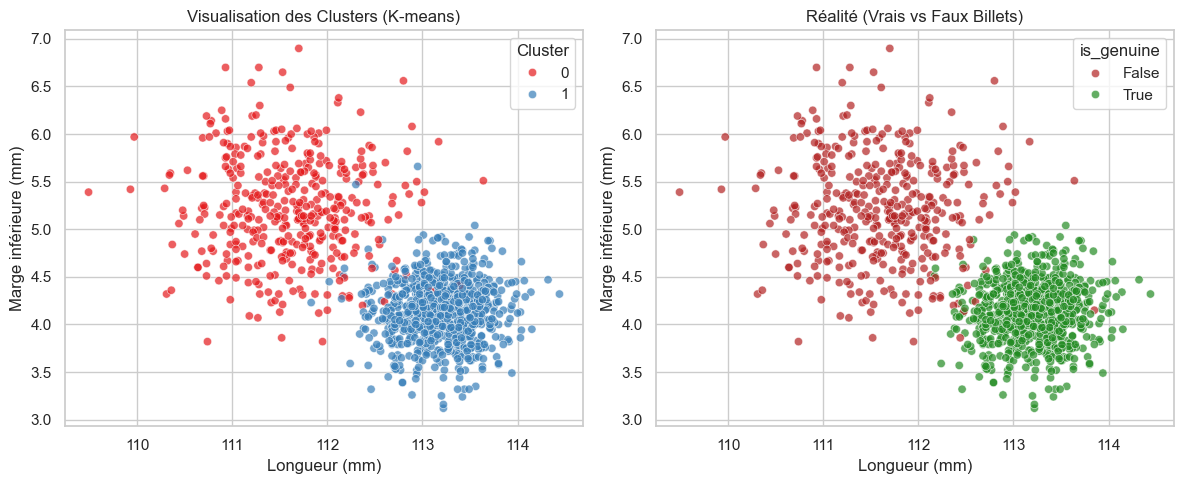

In [39]:
# Visualisation graphique sur les données d'entraînement
plt.figure(figsize=(12, 5))

# Graphique A : Coloré selon les clusters du K-means
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=X_train["length"],
    y=X_train["margin_low"],
    hue=train_clusters,
    palette="Set1",
    alpha=0.7,
)
plt.title("Visualisation des Clusters (K-means)")
plt.xlabel("Longueur (mm)")
plt.ylabel("Marge inférieure (mm)")
plt.legend(title="Cluster")

# Graphique B : Coloré selon la réalité (y_train)
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_train["length"],
    y=X_train["margin_low"],
    hue=y_train,
    palette=couleurs_custom,
    alpha=0.7,
)
plt.title("Réalité (Vrais vs Faux Billets)")
plt.xlabel("Longueur (mm)")
plt.ylabel("Marge inférieure (mm)")

plt.tight_layout()
plt.show()

La comparaison graphique confirme la bonne performance du K-means sur ce jeu de données. Sur les deux sous-graphiques (longueur / marge inférieure), les points colorés par cluster (gauche) et les points colorés par la vraie nature du billet (droite) présentent une organisation très similaire : les faux billets (points orange) occupent bien la même zone géométrique que le Cluster 0. Cela confirme que ces deux variables à elles seules portent déjà une grande partie du signal discriminant, et que la ressemblance morphologique entre vrais et faux billets n'empêche pas ici une séparation non supervisée efficace.


RAPPORT DE CLASSIFICATION : K-MEANS (TEST SET)

              precision    recall  f1-score   support

       False       0.98      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



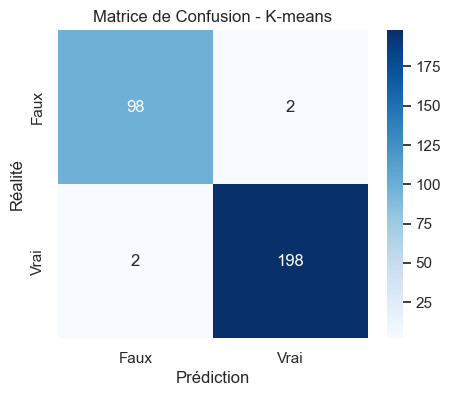

In [40]:
# Générer les prédictions (clusters) sur le jeu de test normalisé
test_clusters = kmeans_sup.predict(X_test_scaled)

# Associer les clusters à la réalité (Cluster 1 = Vrai, Cluster 0 = Faux)
y_pred_kmeans = (test_clusters == 1)

# Calculer la matrice de confusion pour le K-means
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)

# Afficher le rapport de classification textuel
print()
print("RAPPORT DE CLASSIFICATION : K-MEANS (TEST SET)")
print()
print(classification_report(y_test, y_pred_kmeans))

# Tracer la matrice de confusion graphique
plot_confusion_matrix(cm_kmeans, "K-means")

Ce résultat sur le jeu de test (accuracy 0,99, recall 0,98 sur les faux billets) confirme, sur des données non vues pendant l'entraînement du K-means, la correspondance observée sur le train set : le clustering non supervisé constitue à lui seul une méthode de détection quasi aussi performante que les modèles supervisés, ce qui témoigne de la forte séparabilité géométrique entre vrais et faux billets dans ce dataset.

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Évaluation et comparaison des modèles</h2>
</div>

Nous calculons les principales métriques (accuracy, précision, recall, F1-score) pour chacun des 4 modèles, afin de les comparer et de choisir le plus adapté à notre enjeu métier : détecter un maximum de faux billets.

In [41]:
models_preds = {
    "Régression logistique": y_pred_lr,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf,
    "K-means": y_pred_kmeans # remplace y_pred_km par y_pred_kmeans
}

results = []
for name, y_pred in models_preds.items():
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),                           # taux global de bonnes réponses du modèle, toutes classes confondues
        "Précision (Faux)": precision_score(y_test, y_pred, pos_label=False), # mesure la fiabilité du modèle lorsqu'il déclenche une alerte de contrefaçon.
                                                                              # Elle répond à la question : "Quand le modèle me dit qu'un billet est FAUX, quelle est la probabilité qu'il le soit vraiment ?"
        "Recall (Faux)": recall_score(y_test, y_pred, pos_label=False),       # capacité du modèle à capturer la totalité des contrefaçons
        "F1-score (Faux)": f1_score(y_test, y_pred, pos_label=False)          # moyenne équilibrée (harmonique) entre la Précision et le Recall
    })

results_df = pd.DataFrame(results).round(4)
results_df

# On applique le formatage uniquement aux colonnes numériques
formatted_results = results_df.style.format({
    "Accuracy": "{:.4}",
    "Précision (Faux)": "{:.4}",
    "Recall (Faux)": "{:.4}",
    "F1-score (Faux)": "{:.4}"
})

# Affichage du tableau stylisé
formatted_results

,Modèle,Accuracy,Précision (Faux),Recall (Faux),F1-score (Faux)
0,Régression logistique,0.99,0.9899,0.98,0.9849
1,KNN,0.9833,0.9798,0.97,0.9749
2,Random Forest,0.99,0.9899,0.98,0.9849
3,K-means,0.9867,0.98,0.98,0.98


**Observation** :
<br>- la régression logistique et le Random Forest obtiennent les meilleurs résultats, avec l'accuracy à 0.99 et un recall de 0.98 sur les faux billets (soit 98% des faux billets correctement détectés)

**Choix du modèle final** :

Nous retenons le Random Forest comme modèle final. Il obtient les mêmes performances que la régression logistique (accuracy 0.99, recall 0.98 sur les faux billets), mais présente des avantages pratiques : il ne nécessite pas de standardisation (pipeline plus simple), il est plus robuste face à des données futures légèrement différentes, et il permet d'obtenir facilement l'importance des variables pour expliquer ses décisions.

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Optimisation du modèle final</h2>
</div>

In [42]:
recall_faux = make_scorer(recall_score, pos_label=False)   # recall calculé sur la classe "Faux"

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring=recall_faux,   # on optimise le recall sur "Faux"
    cv=5
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [43]:
best_rf = grid_search.best_estimator_   # le meilleur modèle trouvé par GridSearchCV

In [44]:
probas = best_rf.predict_proba(X_test)[:, 1]   # probabilité que le billet soit "Vrai"

for seuil in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_seuil = np.where(probas >= seuil, True, False)
    recall_faux = recall_score(y_test, y_pred_seuil, pos_label=False)
    precision_faux = precision_score(y_test, y_pred_seuil, pos_label=False)
    print(f"Seuil {seuil} -> Recall (Faux): {recall_faux:.3f} | Précision (Faux): {precision_faux:.3f}")

Seuil 0.5 -> Recall (Faux): 0.970 | Précision (Faux): 0.990
Seuil 0.6 -> Recall (Faux): 0.980 | Précision (Faux): 0.980
Seuil 0.7 -> Recall (Faux): 0.980 | Précision (Faux): 0.980
Seuil 0.8 -> Recall (Faux): 1.000 | Précision (Faux): 0.952
Seuil 0.9 -> Recall (Faux): 1.000 | Précision (Faux): 0.926


**Observation** : à partir du seuil 0.8, le modèle atteint un recall de 1.0 sur les faux billets (aucun faux billet n'est classé comme vrai), avec une précision encore élevée de 0.952. C'est le seuil retenu pour notre cas d'usage, où l'enjeu prioritaire est de ne laisser passer aucun faux billet.

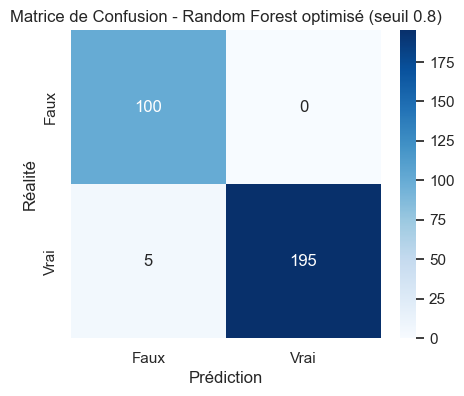

In [45]:
# Générer les prédictions finales en appliquant le seuil retenu de 0.8
y_pred_final = np.where(probas >= 0.8, True, False)

# Calculer la matrice de confusion pour le Random Forest optimisé
cm_final = confusion_matrix(y_test, y_pred_final)

# Tracer la matrice de confusion graphique
plot_confusion_matrix(cm_final, "Random Forest optimisé (seuil 0.8)")

In [46]:
for seuil in np.arange(0.5, 0.85, 0.05):
    y_pred_seuil = np.where(probas >= seuil, True, False)
    recall_faux = recall_score(y_test, y_pred_seuil, pos_label=False)
    precision_faux = precision_score(y_test, y_pred_seuil, pos_label=False)
    fp = ((y_pred_seuil == True) & (y_test == False)).sum()
    fn = ((y_pred_seuil == False) & (y_test == True)).sum()
    print(f"Seuil {seuil:.2f} -> Recall(Faux): {recall_faux:.3f} | Faux positifs: {fp} | Faux négatifs: {fn}")

Seuil 0.50 -> Recall(Faux): 0.970 | Faux positifs: 3 | Faux négatifs: 1
Seuil 0.55 -> Recall(Faux): 0.970 | Faux positifs: 3 | Faux négatifs: 1
Seuil 0.60 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 2
Seuil 0.65 -> Recall(Faux): 0.980 | Faux positifs: 2 | Faux négatifs: 2
Seuil 0.70 -> Recall(Faux): 0.990 | Faux positifs: 1 | Faux négatifs: 2
Seuil 0.75 -> Recall(Faux): 0.990 | Faux positifs: 1 | Faux négatifs: 2
Seuil 0.80 -> Recall(Faux): 1.000 | Faux positifs: 0 | Faux négatifs: 5


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Sauvegarde des objets de Machine Learning</h3>
</div>

In [47]:
import joblib

joblib.dump(imputer, "imputer.joblib")
joblib.dump(best_rf, "random_forest_model.joblib")

# Le seuil n'est pas un objet sklearn : on le sauvegarde à part (json/txt)
import json
with open("model_config.json", "w") as f:
    json.dump({"threshold": 0.8, "features": features_geom}, f)

print("✅ Sauvegarde effectuée")

✅ Sauvegarde effectuée


<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">FIN</h2>
</div>

In [48]:
print("✅ Mission accomplie")

✅ Mission accomplie
